# Checkpoint 2 – APIs, Energias Renováveis e Aprendizado de Máquina

**Integrantes:** _(Rafael Sá, João Melo, Gabriel Souza)_

> **Como executar:** rode as células na ordem (Executar tudo). Se as APIs estiverem fora do ar ou sem acesso, o notebook carrega automaticamente os CSVs que acompanham este repositório.

## 0. Importação das bibliotecas

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEMENTE = 42

# Tarefa 1 – Classificação da fonte renovável (ANEEL)


In [ ]:
URL_CSV_ANEEL = 'https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv'

def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    with urllib.request.urlopen(url, timeout=30) as resposta:
        return json.load(resposta)

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

try:
    URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
    ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
    fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica", "PCH": "Hidráulica", "CGH": "Hidráulica"}
    linhas = []
    for sigla in fontes:
        resp = consultar_api(URL_ANEEL, {"resource_id": ID_RECURSO,
                                         "filters": json.dumps({"SigTipoGeracao": sigla}),
                                         "limit": 1200})
        for r in resp["result"]["records"]:
            pot = numero(r.get("MdaPotenciaOutorgadaKw"))
            lat = numero(r.get("NumCoordNEmpreendimento"))
            lon = numero(r.get("NumCoordEEmpreendimento"))
            if None not in (pot, lat, lon):
                linhas.append([pot, lat, lon, fontes[sigla]])
    dados_aneel = pd.DataFrame(linhas, columns=["potencia_kw", "latitude", "longitude", "fonte"])
    dados_aneel.to_csv("aneel_classificacao_orange.csv", index=False, encoding="utf-8-sig")
    print("Dados obtidos da API da ANEEL.")
except Exception as erro:
    print(f"API da ANEEL indisponível ({type(erro).__name__}). Usando o CSV do repositório.")
    dados_aneel = pd.read_csv(URL_CSV_ANEEL)

dados_aneel.head(10)

Dados obtidos da API da ANEEL.


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


## 1.2 Análise inicial

In [ ]:
dados_aneel.shape

(3876, 4)

In [ ]:
dados_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
dados_aneel.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [ ]:
dados_aneel.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [ ]:
print(dados_aneel['fonte'].unique())
dados_aneel['fonte'].value_counts()

['Solar' 'Eólica' 'Hidráulica']


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


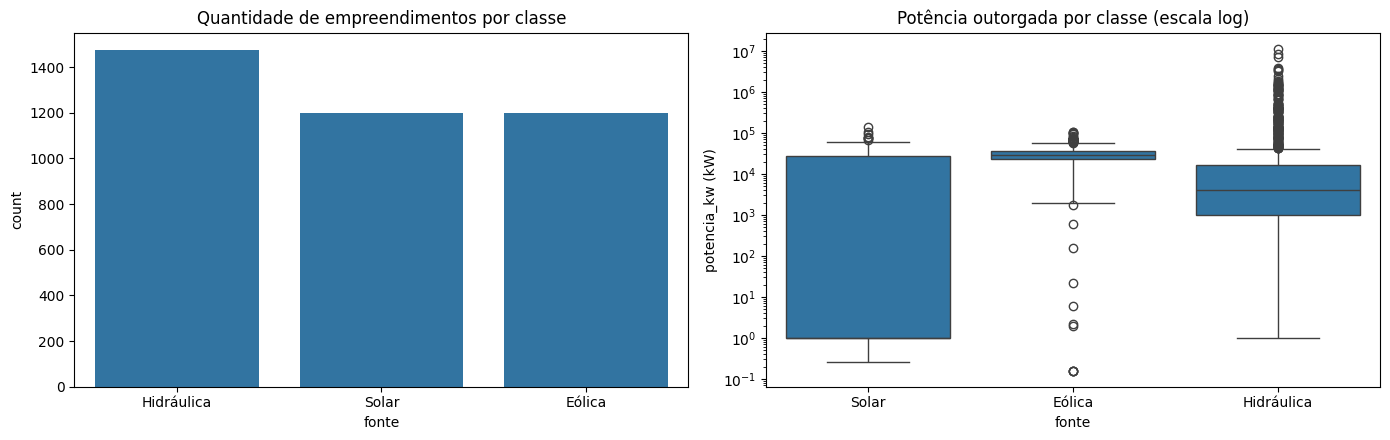

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=dados_aneel, x='fonte', order=dados_aneel['fonte'].value_counts().index, ax=axes[0])
axes[0].set_title('Quantidade de empreendimentos por classe')
axes[0].set_xlabel('fonte')

sns.boxplot(data=dados_aneel, x='fonte', y='potencia_kw', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Potência outorgada por classe (escala log)')
axes[1].set_ylabel('potencia_kw (kW)')
plt.tight_layout()
plt.show()

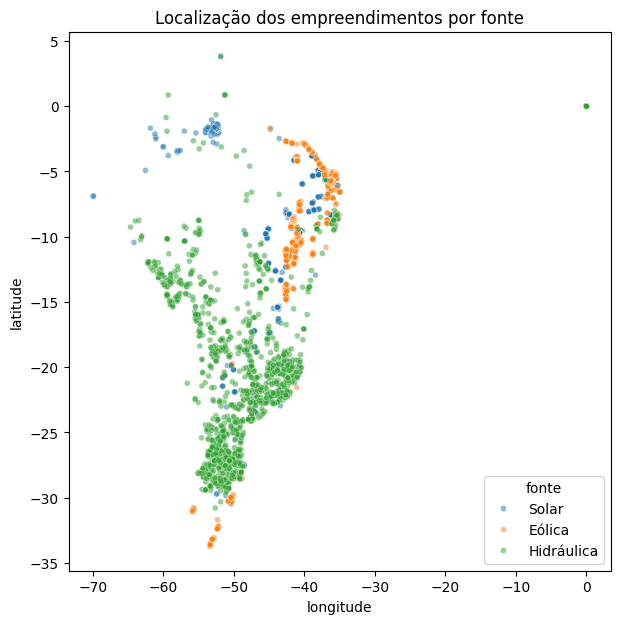

In [ ]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=dados_aneel, x='longitude', y='latitude', hue='fonte', alpha=0.5, s=18)
plt.title('Localização dos empreendimentos por fonte')
plt.show()

**Registro da análise inicial**

- **Linhas e colunas:** 3.876 linhas e 4 colunas (3 entradas numéricas + a classe `fonte`).
- **Valores ausentes:** não há (as linhas incompletas já foram descartadas na geração do CSV).
- **Classes:** Hidráulica (1.476), Solar (1.200) e Eólica (1.200). Há leve desequilíbrio, e a classe Hidráulica é um pouco maior por juntar UHE, PCH e CGH. Isso não é a participação real de cada fonte na matriz brasileira, pois a consulta limita as linhas por tipo.
- **Entradas:** `potencia_kw` tem escala muito maior que latitude e longitude e é muito assimétrica (há usinas de milhões de kW). Por isso padronizamos as entradas nos algoritmos sensíveis à escala (KNN e Regressão Logística).
- **Visualizações:** a potência varia muito entre as classes: a mediana da Eólica é cerca de 29.600 kW (parques), a da Hidráulica cerca de 4.000 kW (com usinas de até 11 milhões de kW) e a da Solar apenas cerca de 1 kW (muitos sistemas pequenos). No mapa, a Eólica se concentra no Nordeste (cerca de 89% dos pontos), a Hidráulica fica mais no Sudeste/Sul/Centro-Oeste e a Solar se espalha pelo país.

In [ ]:
X = dados_aneel[['potencia_kw', 'latitude', 'longitude']]

y = dados_aneel['fonte']

print(X.head())
print()
print(y.head())

   potencia_kw   latitude  longitude
0        20.48 -10.442778 -64.151944
1      5000.00  -6.003889 -40.274722
2        12.26 -23.557778 -46.734000
3         3.00 -23.558889 -46.735000
4         1.70 -23.493819 -46.845000

0    Solar
1    Solar
2    Solar
3    Solar
4    Solar
Name: fonte, dtype: object


# Separação entre treino e teste

Divisão **estratificada** (80% treino / 20% teste) com semente fixa. A estratificação mantém a proporção de cada classe nos dois conjuntos. Os três modelos usam **exatamente a mesma divisão**.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMENTE)

print('Total:  ', X.shape[0])
print('Treino: ', X_train.shape[0])
print('Teste:  ', X_test.shape[0])
print()
print('Proporção das classes no teste:')
print(y_test.value_counts(normalize=True).round(3))

Total:   3876
Treino:  3100
Teste:   776

Proporção das classes no teste:
fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


In [ ]:
modelos_clf = {
    'KNN':                 make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Regressão Logística': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEMENTE),
}

previsoes_clf = {}
for nome, modelo in modelos_clf.items():
    modelo.fit(X_train, y_train)
    previsoes_clf[nome] = modelo.predict(X_test)
    print(f'{nome}: treinado')

KNN: treinado
Regressão Logística: treinado
Random Forest: treinado


In [ ]:
classes = modelos_clf['Regressão Logística'].classes_
probabilidades = modelos_clf['Regressão Logística'].predict_proba(X_test)
print('Ordem das classes:', list(classes))
pd.DataFrame(probabilidades[:10], columns=classes).round(3)

Ordem das classes: ['Eólica', 'Hidráulica', 'Solar']


,Eólica,Hidráulica,Solar
0,0.064,0.921,0.015
1,0.604,0.175,0.221
2,0.696,0.159,0.145
3,0.067,0.916,0.018
4,0.078,0.901,0.021
5,0.053,0.047,0.900
6,0.041,0.944,0.015
7,0.341,0.271,0.389
8,0.383,0.395,0.222
9,0.451,0.499,0.050


In [ ]:
linhas = []
for nome, previsao in previsoes_clf.items():
    linhas.append({
        'Algoritmo': nome,
        'Accuracy': accuracy_score(y_test, previsao),
        'Precision (macro)': precision_score(y_test, previsao, average='macro'),
        'Recall (macro)': recall_score(y_test, previsao, average='macro'),
        'F1 (macro)': f1_score(y_test, previsao, average='macro'),
    })

comparacao_clf = pd.DataFrame(linhas).set_index('Algoritmo')
comparacao_clf.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Algoritmo,,,,
KNN,0.9665,0.9677,0.9649,0.9662
Regressão Logística,0.8235,0.8275,0.8200,0.8182
Random Forest,0.9755,0.9769,0.9741,0.9753


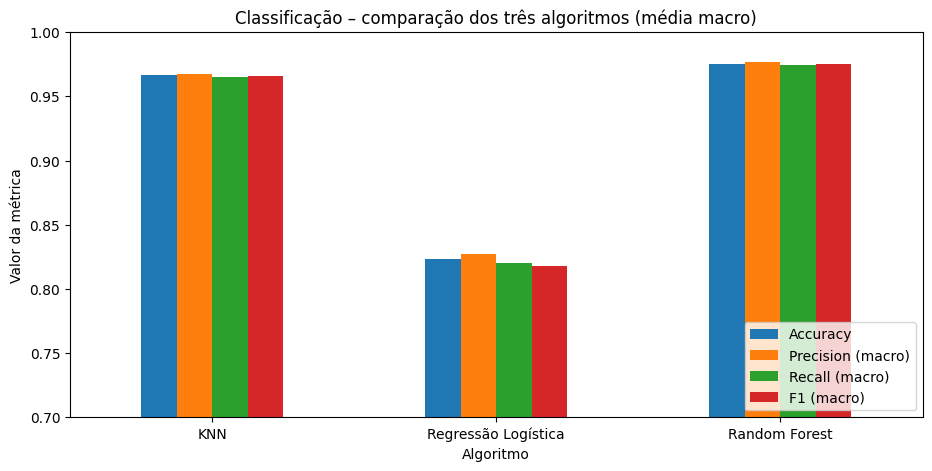

In [ ]:
comparacao_clf.plot(kind='bar', figsize=(11, 5), ylim=(0.7, 1.0))
plt.title('Classificação – comparação dos três algoritmos (média macro)')
plt.ylabel('Valor da métrica')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

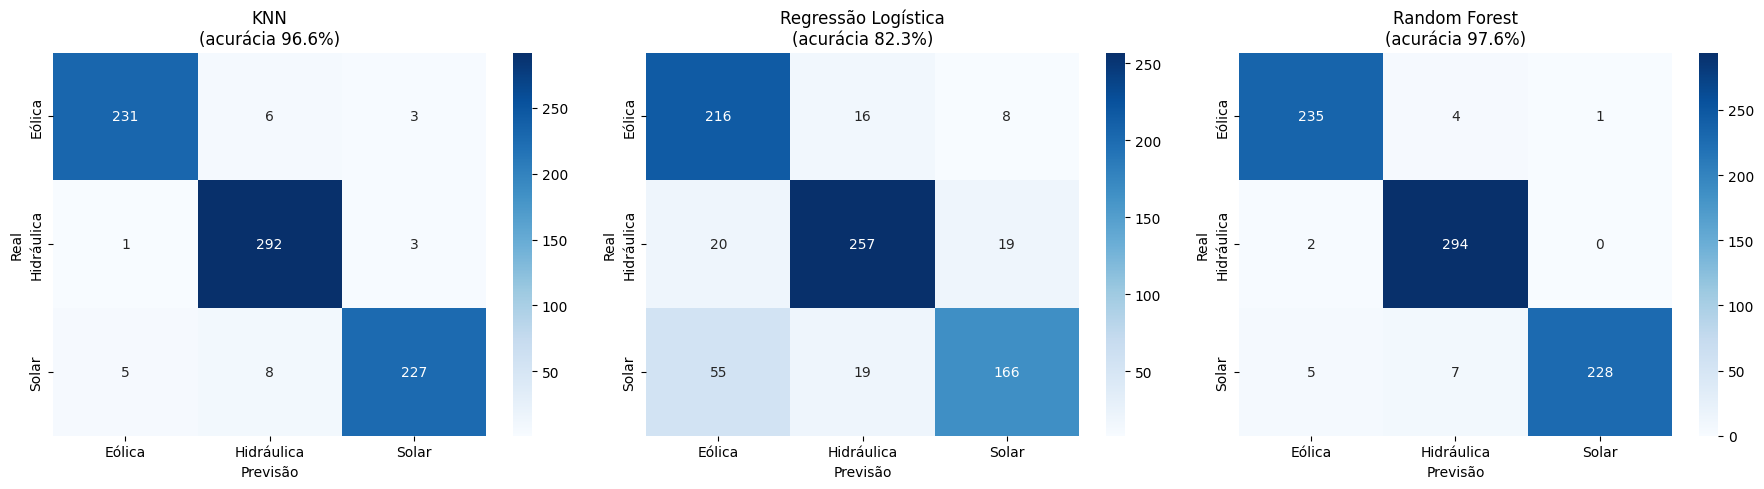

In [ ]:
ordem = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, previsao) in zip(axes, previsoes_clf.items()):
    mc = confusion_matrix(y_test, previsao, labels=ordem)
    sns.heatmap(mc, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=ordem, yticklabels=ordem)
    ax.set_title(f'{nome}\n(acurácia {100*accuracy_score(y_test, previsao):.1f}%)')
    ax.set_xlabel('Previsão')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

In [ ]:
for nome, previsao in previsoes_clf.items():
    mc = pd.DataFrame(confusion_matrix(y_test, previsao, labels=ordem), index=ordem, columns=ordem)
    erros = [(r, p, mc.loc[r, p]) for r in ordem for p in ordem if r != p]
    erros = sorted(erros, key=lambda t: -t[2])[:3]
    print(nome)
    for real, prev, qtd in erros:
        print(f'   real {real} -> previsto {prev}: {qtd}')

KNN
   real Solar -> previsto Hidráulica: 8
   real Eólica -> previsto Hidráulica: 6
   real Solar -> previsto Eólica: 5
Regressão Logística
   real Solar -> previsto Eólica: 55
   real Hidráulica -> previsto Eólica: 20
   real Hidráulica -> previsto Solar: 19
Random Forest
   real Solar -> previsto Hidráulica: 7
   real Solar -> previsto Eólica: 5
   real Eólica -> previsto Hidráulica: 4


# Tarefa 2 – Regressão da radiação solar (Open-Meteo)


In [ ]:
URL_CSV_METEO = 'https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/meteo_regressao_orange.csv'

try:
    URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
    nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover", "wind_speed_10m", "shortwave_radiation"]
    resp = consultar_api(URL_METEO, {
        "latitude": -9.39, "longitude": -40.50,
        "start_date": "2025-04-01", "end_date": "2025-06-30",
        "timezone": "America/Recife", "hourly": ",".join(nomes_api)})
    h = resp["hourly"]
    linhas = []
    for i, data_hora in enumerate(h["time"]):
        hora = int(data_hora[11:13])
        valores = [h[n][i] for n in nomes_api]
        if 7 <= hora <= 17 and None not in valores:
            linhas.append([data_hora, *valores[:4], hora, valores[4]])
    dados_meteo = pd.DataFrame(linhas, columns=["data_hora", "temperatura_c", "umidade_pct",
                                                "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    dados_meteo.to_csv("meteo_regressao_orange.csv", index=False, encoding="utf-8-sig")
    print("Dados obtidos da API Open-Meteo.")
except Exception as erro:
    print(f"API Open-Meteo indisponível ({type(erro).__name__}). Usando o CSV do repositório.")
    dados_meteo = pd.read_csv(URL_CSV_METEO)

dados_meteo.head(10)

Dados obtidos da API Open-Meteo.


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0
5,2025-04-01T12:00,34.2,31,36,19.2,12,905.0
6,2025-04-01T13:00,35.0,30,50,19.5,13,910.0
7,2025-04-01T14:00,35.0,30,19,17.1,14,733.0
8,2025-04-01T15:00,35.3,30,30,17.3,15,699.0
9,2025-04-01T16:00,35.0,30,18,17.6,16,443.0


## 2.2 Análise inicial

In [ ]:
dados_meteo.shape

(1001, 7)

In [ ]:
dados_meteo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [ ]:
dados_meteo.isnull().sum()

,0
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0


In [ ]:
dados_meteo.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


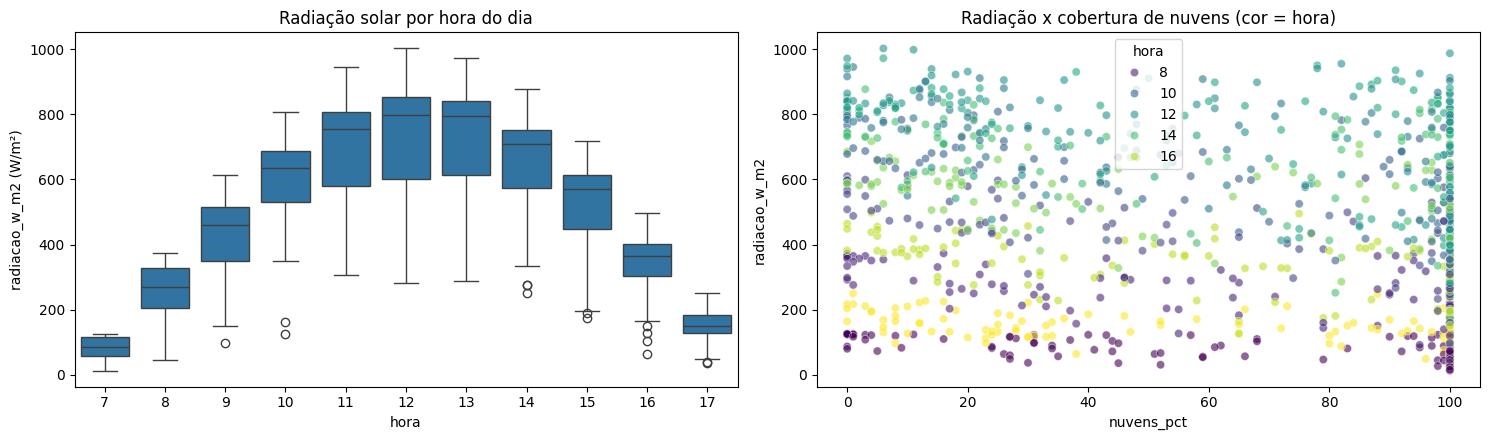

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=dados_meteo, x='hora', y='radiacao_w_m2', ax=axes[0])
axes[0].set_title('Radiação solar por hora do dia')
axes[0].set_ylabel('radiacao_w_m2 (W/m²)')

sns.scatterplot(data=dados_meteo, x='nuvens_pct', y='radiacao_w_m2', hue='hora', palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('Radiação x cobertura de nuvens (cor = hora)')
plt.tight_layout()
plt.show()

In [ ]:
dados_meteo.drop(columns='data_hora').corr()['radiacao_w_m2'].drop('radiacao_w_m2').round(3)

,radiacao_w_m2
temperatura_c,0.643
umidade_pct,-0.596
nuvens_pct,-0.180
vento_kmh,-0.229
hora,0.120


**Registro da análise inicial**

- **Tamanho:** 1.001 linhas (uma por hora, de 7h a 17h) e 7 colunas. Não há valores ausentes.
- **Hora do dia:** o boxplot mostra que a radiação cresce de manhã, tem o pico por volta do meio-dia e cai à tarde (formato de "sino"). A relação **não é linear**: a correlação linear simples com `hora` é só +0,12, embora a hora seja muito importante (veja a importância das variáveis no Random Forest, mais abaixo).
- **Correlações lineares com a radiação:** temperatura (+0,64) e umidade (−0,60) são as mais fortes (a temperatura sobe e a umidade cai durante o dia, então elas também refletem a hora). Nuvens (−0,18) e vento (−0,23) têm correlação linear fraca.

# Definição de X e y e divisão temporal

In [ ]:
dados_meteo = dados_meteo.sort_values('data_hora').reset_index(drop=True)

colunas_entrada = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
X2 = dados_meteo[colunas_entrada]
y2 = dados_meteo['radiacao_w_m2']

corte = int(len(dados_meteo) * 0.8)
X2_train, X2_test = X2.iloc[:corte], X2.iloc[corte:]
y2_train, y2_test = y2.iloc[:corte], y2.iloc[corte:]

print('Treino:', X2_train.shape[0], 'registros  de', dados_meteo['data_hora'].iloc[0], 'até', dados_meteo['data_hora'].iloc[corte-1])
print('Teste: ', X2_test.shape[0], 'registros  de', dados_meteo['data_hora'].iloc[corte], 'até', dados_meteo['data_hora'].iloc[-1])

Treino: 800 registros  de 2025-04-01T07:00 até 2025-06-12T14:00
Teste:  201 registros  de 2025-06-12T15:00 até 2025-06-30T17:00


## 2.4 Os três regressores

| Modelo | Por que foi escolhido | Observação |
|---|---|---|
| **Regressão Linear** | Modelo-base simples e interpretável | Não captura o formato de "sino" da radiação ao longo do dia |
| **Árvore de Decisão** (`max_depth=6`) | Aprende regras não lineares (ex.: hora próxima do meio-dia e poucas nuvens) | A profundidade limitada reduz o sobreajuste |
| **Random Forest** | Média de várias árvores: mais estável e geralmente mais precisa | Não exige padronização |

Nenhum dos três exige padronização aqui (árvores são insensíveis à escala, e a Regressão Linear não muda de previsão com ela), então não foi aplicada transformação. Isso evita qualquer vazamento do teste.

In [ ]:
modelos_reg = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=6, random_state=SEMENTE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEMENTE),
}

previsoes_reg = {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X2_train, y2_train)
    previsoes_reg[nome] = modelo.predict(X2_test)
    print(f'{nome}: treinado')

Regressão Linear: treinado
Árvore de Decisão: treinado
Random Forest: treinado


## 2.5 Métricas e comparação

Mesma divisão temporal para os três modelos. MAE em W/m², MSE em (W/m²)² e R² (adimensional).

In [ ]:
linhas = []
for nome, previsao in previsoes_reg.items():
    linhas.append({
        'Algoritmo': nome,
        'MAE (W/m²)': mean_absolute_error(y2_test, previsao),
        'MSE ((W/m²)²)': mean_squared_error(y2_test, previsao),
        'R²': r2_score(y2_test, previsao),
    })

comparacao_reg = pd.DataFrame(linhas).set_index('Algoritmo')
comparacao_reg.round(4)

,MAE (W/m²),MSE ((W/m²)²),R²
Algoritmo,,,
Regressão Linear,145.2049,30034.2011,0.3598
Árvore de Decisão,90.9377,15127.0271,0.6776
Random Forest,66.8042,7307.4179,0.8442


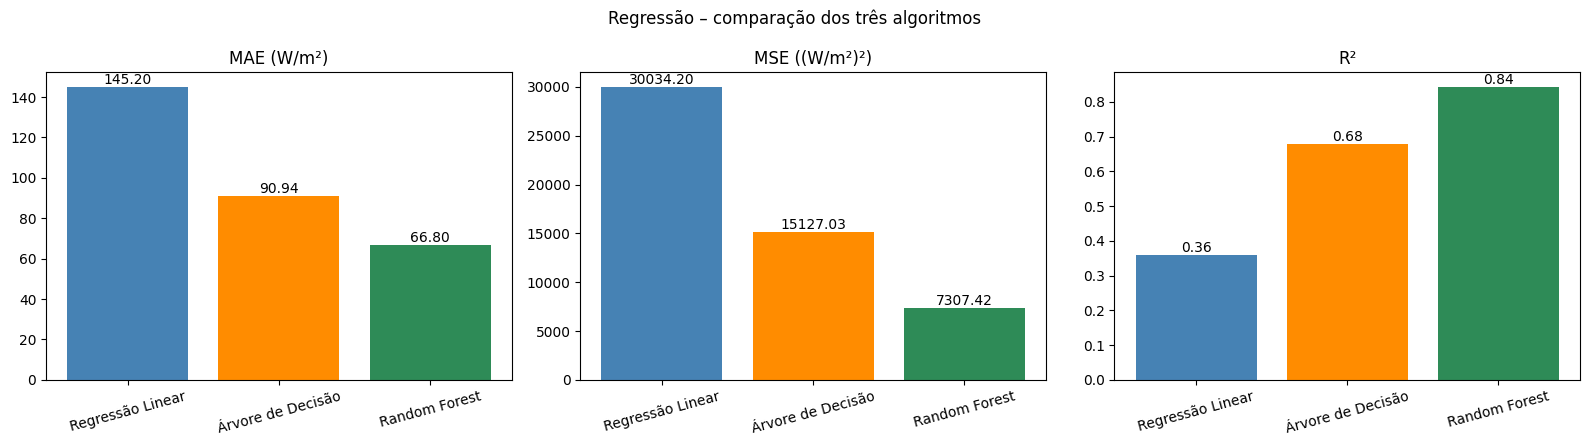

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cores = ['steelblue', 'darkorange', 'seagreen']
for ax, metrica in zip(axes, comparacao_reg.columns):
    barras = ax.bar(comparacao_reg.index, comparacao_reg[metrica], color=cores)
    ax.bar_label(barras, fmt='%.2f')
    ax.set_title(metrica)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Regressão – comparação dos três algoritmos')
plt.tight_layout()
plt.show()

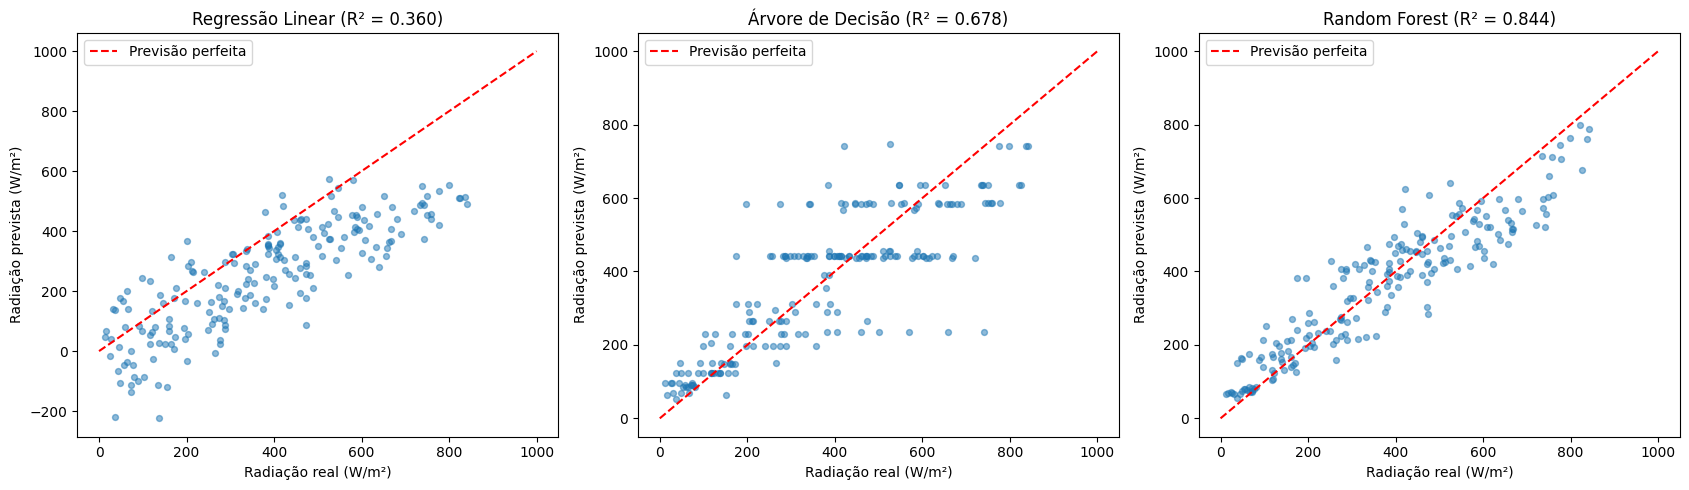

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
limite = [0, max(y2_test.max(), 1000)]
for ax, (nome, previsao) in zip(axes, previsoes_reg.items()):
    ax.scatter(y2_test, previsao, alpha=0.5, s=18)
    ax.plot(limite, limite, 'r--', label='Previsão perfeita')
    ax.set_title(f'{nome} (R² = {r2_score(y2_test, previsao):.3f})')
    ax.set_xlabel('Radiação real (W/m²)')
    ax.set_ylabel('Radiação prevista (W/m²)')
    ax.legend()
plt.tight_layout()
plt.show()

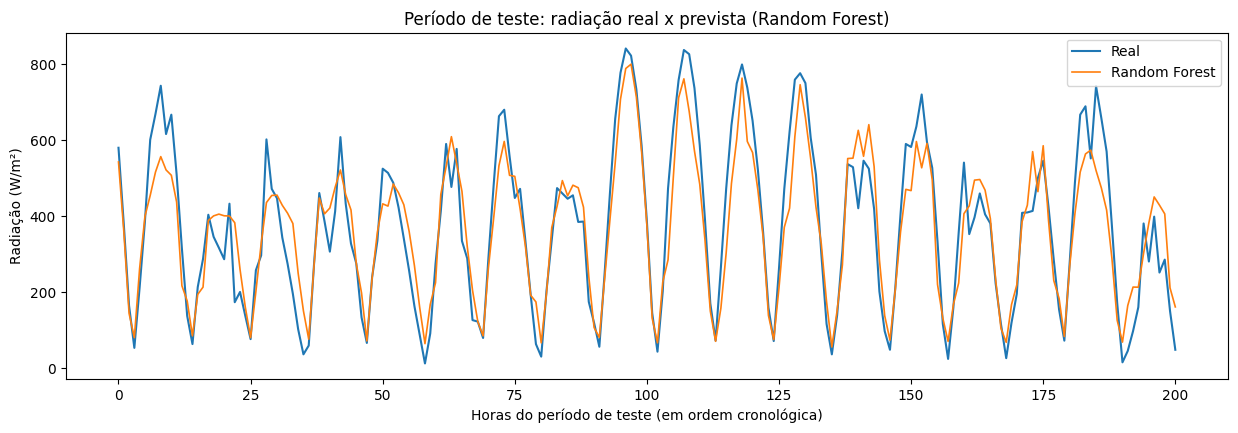

In [ ]:
plt.figure(figsize=(15, 4.5))
plt.plot(range(len(y2_test)), y2_test.values, label='Real', linewidth=1.5)
plt.plot(range(len(y2_test)), previsoes_reg['Random Forest'], label='Random Forest', linewidth=1.2)
plt.title('Período de teste: radiação real x prevista (Random Forest)')
plt.xlabel('Horas do período de teste (em ordem cronológica)')
plt.ylabel('Radiação (W/m²)')
plt.legend()
plt.show()

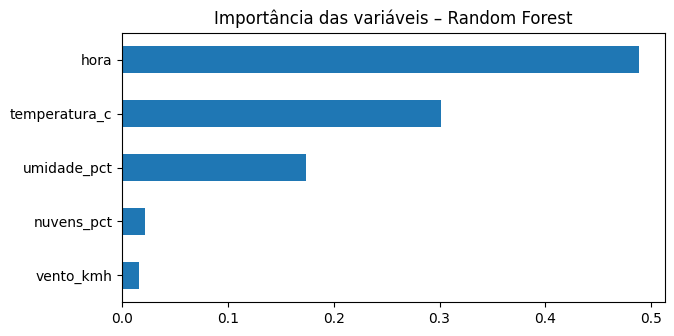

,0
hora,0.488
temperatura_c,0.301
umidade_pct,0.173
nuvens_pct,0.022
vento_kmh,0.015


In [ ]:
importancias = pd.Series(modelos_reg['Random Forest'].feature_importances_, index=colunas_entrada).sort_values()
importancias.plot(kind='barh', figsize=(7, 3.5), title='Importância das variáveis – Random Forest')
plt.show()
importancias.sort_values(ascending=False).round(3)

# Resumo geral

| Tarefa | Melhor algoritmo | Resultado principal |
|---|---|---|
| 1 – Classificação da fonte (ANEEL) | Random Forest | Accuracy 97,6% e F1 macro 0,975 |
| 2 – Radiação solar em Petrolina | Random Forest | MAE 66,8 W/m², R² 0,844 |